# Knight's Walk

In [2]:
import numpy as np
import matplotlib.pyplot as plt

### Part 1 - Initialize the board

https://www.youtube.com/watch?v=RGQe8waGJ4w (runtime: 6:12)

We will store the chess board in a 2d- numpy array of integers. The size of the board is $(2n+1)$-by-$(2n+1)$, for a given integer $n$. This means the board extends from the center square by $n$ steps in all directions.

The first step is to initialize the board by filling it with the integers described in the video. Finish the implementation of the function definition in the cell below such that it returns this "spiral pattern" for any given input parameter $n$.

An example is given below: for the following input
```python
board = initialize_board(3)
```
the correct output is
```julia
7×7 Array{Int64,2}:
 37  36  35  34  33  32  31
 38  17  16  15  14  13  30
 39  18   5   4   3  12  29
 40  19   6   1   2  11  28
 41  20   7   8   9  10  27
 42  21  22  23  24  25  26
 43  44  45  46  47  48  49
```

Test your function for various values of $n$ to make sure it is correct before you continue.

*Hints*:
- Note that since Python uses 0-based indexing, the center square of the array `board` is given by element `board[n,n]`.
- After the center $1$ has been placed, there are exactly $n$ "circles" of numbers of increasing radius. This is naturally implemented using a for-loop.
- In each "circle", there are 4 segments going up, left, down, and right. These are also naturally implemented using a sequence of 4 for-loops.

In [ ]:
def initialize_board(n):
    board = np.zeros(((2*n+1),(2*n+1)),dtype='int')
    board[n,n]=1
    num = 2
    cicli = 1

    #Posizioni
    direzioni = np.array((0,1),(-1,0),(0,-1),(1,0))   

    while num >= (2,(2*n+1)*(2*n+1)):  #finchè il numero è minore del numero massimo di numeri nella board
        for i,dir in enumerate(direzioni):
            posizione = [n,n] + dir
            for _ in range(cicli): 
                board[posizione]= num   #assegnazione numero

                num += 1  #agg numero
            cicli += 1
                
            
    return board

In [44]:
def initialize_board(n):
    size = 2*n + 1
    max_num = size * size
    board = np.zeros((size, size), dtype=int)

    r, c = n, n
    board[r, c] = 1
    num = 2
    cicli = 1

    direzioni = [(0, 1), (-1, 0), (0, -1), (1, 0)]  # destra, su, sinistra, giù

    while num <= max_num:
        for i, (dr, dc) in enumerate(direzioni):
            for _ in range(cicli):
                if num > max_num:
                    return board
                r += dr
                c += dc
                board[r, c] = num
                num += 1
            if i % 2 == 1:      # dopo "su" e dopo "giù" il tratto si allunga
                cicli += 1
    return board

In [49]:
# Use the initialize_board function to create a board
n=2
board=initialize_board(4)



    
board

array([[65, 64, 63, 62, 61, 60, 59, 58, 57],
       [66, 37, 36, 35, 34, 33, 32, 31, 56],
       [67, 38, 17, 16, 15, 14, 13, 30, 55],
       [68, 39, 18,  5,  4,  3, 12, 29, 54],
       [69, 40, 19,  6,  1,  2, 11, 28, 53],
       [70, 41, 20,  7,  8,  9, 10, 27, 52],
       [71, 42, 21, 22, 23, 24, 25, 26, 51],
       [72, 43, 44, 45, 46, 47, 48, 49, 50],
       [73, 74, 75, 76, 77, 78, 79, 80, 81]])

### Part 2 - Simulate the walk

Next we will write the function to simulate the walk and produce the sequence. This function will take an initialized board as input, and produce a list of numbers as well as the corresponding x- and y-coordinates.

For example, the following input:
```julia
board = initialize_board(2)
display(board)
seq, xs, ys = simulate_walk(board);
print("Sequence = ", seq)
print("x-coordinates = ", xs)
print("y-coordinates = ", ys)
```
should produce the following correct output:
```julia
5×5 Array{Int64,2}:
 17  16  15  14  13
 18   5   4   3  12
 19   6   1   2  11
 20   7   8   9  10
 21  22  23  24  25
Sequence = [1, 10, 3, 6, 9, 4, 7, 2, 5, 8, 11, 14]
x-coordinates = [0, 2, 1, -1, 1, 0, -1, 1, -1, 0, 2, 1]
y-coordinates = [0, 1, -1, 0, 1, -1, 1, 0, -1, 1, 0, -2]
```

Again test your code, first using small values of $n$ as shown above, which makes it easier to look at the results and find errors.

*Hints*:
- It is convenient to create another 2d-array of booleans, indicating if a square has been visited or not.
- Make sure you never allow the knight to jump outside the board. That is, the only valid positions are $n$ steps from the center square in either direction

In [64]:
def simulate_walk(board):
    sequence = []; x_coordinates = []; y_coordinates = []
    check_array = np.zeros(board.shape, dtype=bool)
    lunghezza, larghezza = board.shape
    n = lunghezza // 2
    pos_attuale = np.array([n, n])              # (1) array, non lista
    check_array[n, n] = True                    # (2) indici separati

    lista_valori = []

    mov_cavallo = np.array([(-2,-1),(-2,1),(-1,2),(1,2),(2,1),(2,-1),(1,-2),(-1,-2)])

    controllo = True

    while controllo:
        for i, dir in enumerate(mov_cavallo):
            x_, y_ = pos_attuale + dir

            # (3) prima i limiti, poi la maschera
            if x_ < 0 or x_ >= lunghezza or y_ < 0 or y_ >= larghezza:
                continue
            if check_array[x_, y_]:
                continue
            lista_valori.append((board[x_, y_], x_, y_))     # (4) valore + posizione

        if len(lista_valori) == 0:
            controllo = False
            break                                            # (5) esci, altrimenti min([]) dà ValueError

        min_num, x, y = min(lista_valori)                    # (6) x, y = casella scelta

        # aggiornamento liste
        sequence.append(min_num)
        lista_valori.clear()
        x_coordinates.append(x)
        y_coordinates.append(y)
        check_array[x, y] = True
        pos_attuale = np.array([x, y])                       # ci si sposta sulla casella scelta

    return (sequence, x_coordinates, y_coordinates)

simulate_walk(board)


([np.int64(10),
  np.int64(3),
  np.int64(6),
  np.int64(9),
  np.int64(4),
  np.int64(7),
  np.int64(2),
  np.int64(5),
  np.int64(8),
  np.int64(11),
  np.int64(14),
  np.int64(29),
  np.int64(32),
  np.int64(15),
  np.int64(12),
  np.int64(27),
  np.int64(24),
  np.int64(45),
  np.int64(20),
  np.int64(23),
  np.int64(44),
  np.int64(41),
  np.int64(18),
  np.int64(35),
  np.int64(38),
  np.int64(19),
  np.int64(16),
  np.int64(33),
  np.int64(30),
  np.int64(53),
  np.int64(26),
  np.int64(47),
  np.int64(22),
  np.int64(43),
  np.int64(70),
  np.int64(21),
  np.int64(40),
  np.int64(17),
  np.int64(34),
  np.int64(13),
  np.int64(28),
  np.int64(25),
  np.int64(46),
  np.int64(75),
  np.int64(42),
  np.int64(69),
  np.int64(104),
  np.int64(37),
  np.int64(62),
  np.int64(95),
  np.int64(58),
  np.int64(55),
  np.int64(86),
  np.int64(51),
  np.int64(48),
  np.int64(77),
  np.int64(114),
  np.int64(73),
  np.int64(108),
  np.int64(151),
  np.int64(68),
  np.int64(103),
  np.int64(

In [65]:
board = initialize_board(2)
display(board)
sequence,x_coordinates,y_coordinates = simulate_walk(board)
print("Sequence = ", sequence)
print("x-coordinates = ", x_coordinates)
print("y-coordinates = ", y_coordinates)

array([[17, 16, 15, 14, 13],
       [18,  5,  4,  3, 12],
       [19,  6,  1,  2, 11],
       [20,  7,  8,  9, 10],
       [21, 22, 23, 24, 25]])

Sequence =  [np.int64(10), np.int64(3), np.int64(6), np.int64(9), np.int64(4), np.int64(7), np.int64(2), np.int64(5), np.int64(8), np.int64(11), np.int64(14)]
x-coordinates =  [np.int64(3), np.int64(1), np.int64(2), np.int64(3), np.int64(1), np.int64(3), np.int64(2), np.int64(1), np.int64(3), np.int64(2), np.int64(0)]
y-coordinates =  [np.int64(4), np.int64(3), np.int64(1), np.int64(3), np.int64(2), np.int64(1), np.int64(3), np.int64(1), np.int64(2), np.int64(4), np.int64(3)]


last element =  2084
with coordinates (77,110)


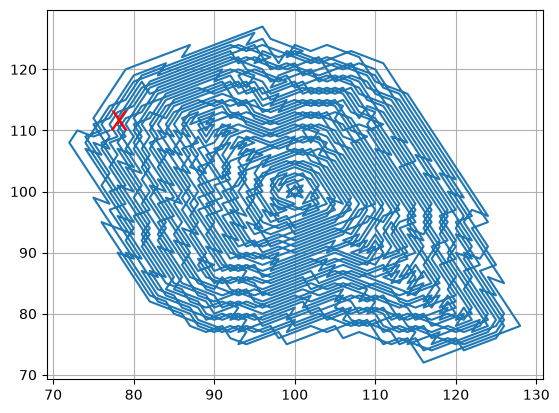

In [66]:
n = 100
board = initialize_board(n)
sequence,x_coordinates,y_coordinates = simulate_walk(board)
print("last element = ", int(sequence[-1]))
print(f"with coordinates ({x_coordinates[-1]},{y_coordinates[-1]})")
# y_coordinates = np.negative(y_coordinates)
plt.plot(x_coordinates, y_coordinates)
plt.annotate('X',xy=(x_coordinates[-1],y_coordinates[-1]), color='red', size=20)
plt.grid()